In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



In [4]:
r_model=joblib.load("training/retention_predictor.pkl")
m_model=joblib.load("training/xgb_model.pkl")

# A SAMPLE STUDENT
data=pd.read_csv("training/memory_strength_dataset_cleaned_2.csv")
data.head(5)

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,retention,S
0,56.312171,7,7.190609,7,85.791568,2,61.106404,114.327011
1,2.495917,1,8.053991,6,10.132390,3,98.713498,192.757354
2,24.313371,9,6.673295,9,59.508954,2,72.257539,74.825677
3,235.882474,6,4.193669,7,12.255043,0,0.247996,39.316935
4,138.330092,6,7.269977,8,15.846049,1,14.729763,72.223718


Revision 1 -> S = 87.15
Revision 2 -> S = 89.92
Revision 3 -> S = 93.29
Revision 4 -> S = 96.77
Revision 5 -> S = 99.03


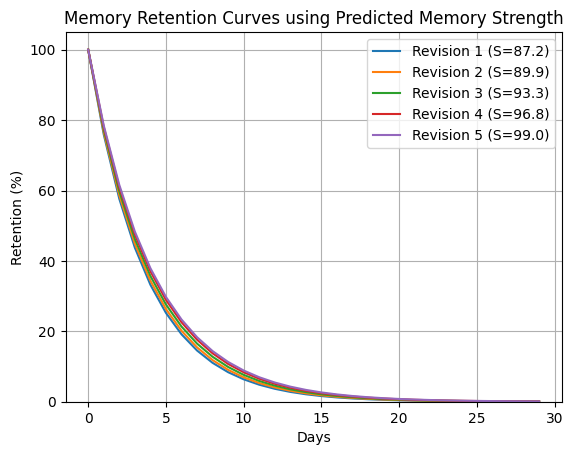

In [17]:
days=np.arange(0,30,1)

sleep_duration=8
topic_difficulty=2
study_duration=60
session_time=1

for nth in range(1,6):
    thres_retention=80
    revision_timing = 24

    input_data = pd.DataFrame([{
        "nth_revision": nth,
        "sleep_duration": sleep_duration,
        "topic_difficulty": topic_difficulty,
        "study_duration": study_duration,
        "session_time": session_time,
        "retention": thres_retention,
        "revision_timing": revision_timing
    }])

    s=m_model.predict(input_data)[0]
    print(f"Revision {nth} -> S = {s:.2f}")
    ret_curve=100*np.exp((-days*24)/s)
    
    plt.plot(days,ret_curve,label=f"Revision {nth} (S={s:.1f})")
plt.title("Memory Retention Curves using Predicted Memory Strength")
plt.xlabel("Days")
plt.ylabel("Retention (%)")
plt.ylim(0, 105)
plt.grid(True)
plt.legend()
plt.show()

Revision 1 -> S = 84.59
Revision 2 -> S = 90.69
Revision 3 -> S = 94.04
Revision 4 -> S = 97.63
Revision 5 -> S = 99.94


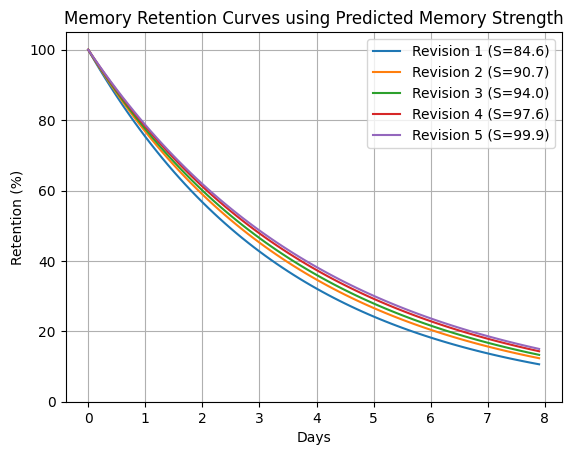

In [18]:
days=np.arange(0,8,0.1)

sleep_duration=8
topic_difficulty=5
study_duration=60
session_time=1

for nth in range(1,6):
    thres_retention=80
    revision_timing = 24

    input_data = pd.DataFrame([{
        "nth_revision": nth,
        "sleep_duration": sleep_duration,
        "topic_difficulty": topic_difficulty,
        "study_duration": study_duration,
        "session_time": session_time,
        "retention": thres_retention,
        "revision_timing": revision_timing
    }])

    s=m_model.predict(input_data)[0]
    print(f"Revision {nth} -> S = {s:.2f}")
    ret_curve=100*np.exp((-days*24)/s)
    
    plt.plot(days,ret_curve,label=f"Revision {nth} (S={s:.1f})")
plt.title("Memory Retention Curves using Predicted Memory Strength")
plt.xlabel("Days")
plt.ylabel("Retention (%)")
plt.ylim(0, 105)
plt.grid(True)
plt.legend()
plt.show()

In [19]:
data.groupby("nth_revision")["S"].mean()

nth_revision
0    48.225989
1    62.391279
2    72.365197
3    77.301162
4    83.672295
5    87.158178
6    90.107576
7    94.708874
8    98.119768
9    98.945603
Name: S, dtype: float64

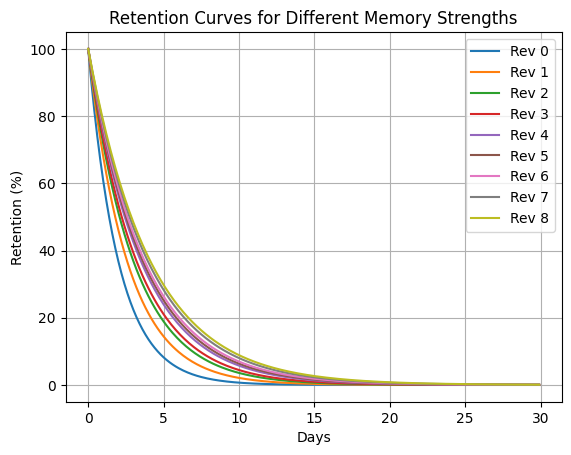

In [20]:


days=np.arange(0,30,0.1)

S_values=[48,62,72,77,84,87,90,95,99]

for i,s in enumerate(S_values):
    retention=100*np.exp((-days*24)/s)
    plt.plot(days,retention,label=f"Rev {i}")

plt.xlabel("Days")
plt.ylabel("Retention (%)")
plt.title("Retention Curves for Different Memory Strengths")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import numpy as np

for s in [48,62,72,77,84,87,90,95,99]:
    t = -s*np.log(0.8)
    print(f"S={s:.1f} -> {t:.2f} hours")

S=48.0 -> 10.71 hours
S=62.0 -> 13.83 hours
S=72.0 -> 16.07 hours
S=77.0 -> 17.18 hours
S=84.0 -> 18.74 hours
S=87.0 -> 19.41 hours
S=90.0 -> 20.08 hours
S=95.0 -> 21.20 hours
S=99.0 -> 22.09 hours
